This code displays the model building process for a classifier that can determine whether or not a photo object is recyclable.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
data_dir = "/content/drive/MyDrive/#3 - Data Science Project/RealWaste"

KeyboardInterrupt: 

In [ ]:
data_dir = "/content/drive/MyDrive/#3 - Data Science Project/RealWaste"

In [ ]:
# We begin by preprocessing the data
# First, remove the “plastic” image category. Then, group image categories based on whether or not they are recyclable

import os
import shutil

base_dir = "/content/drive/MyDrive/#3 - Data Science Project/RealWaste"
new_base_dir = "/content/drive/MyDrive/#3 - Data Science Project/CleanedDataset"

recyclable_dir = os.path.join(new_base_dir, "Recyclable")
non_recyclable_dir = os.path.join(new_base_dir, "Non_Recyclable")

os.makedirs(recyclable_dir, exist_ok=True)
os.makedirs(non_recyclable_dir, exist_ok=True)

In [ ]:
recyclable_classes = ["Cardboard", "Paper", "Glass", "Metal"]
non_recyclable_classes = ["Miscellaneous Trash", "Textile Trash", "Food Organics", "Vegetation"]

In [ ]:
def copy_images(class_list, target_dir):
    for class_name in class_list:
        class_path = os.path.join(base_dir, class_name)

        if not os.path.exists(class_path):
            print(f"Skipping missing folder: {class_name}")
            continue

        for img_name in os.listdir(class_path):
            src = os.path.join(class_path, img_name)

            # Add class name to avoid filename collisions
            dst = os.path.join(target_dir, f"{class_name}_{img_name}")

            try:
                shutil.copy(src, dst)
            except Exception as e:
                print(f"Error copying {src}: {e}")

In [ ]:
copy_images(recyclable_classes, recyclable_dir)
copy_images(non_recyclable_classes, non_recyclable_dir)

Skipping missing folder: Cardboard
Skipping missing folder: Paper
Skipping missing folder: Glass
Skipping missing folder: Metal
Skipping missing folder: Miscellaneous Trash
Skipping missing folder: Textile Trash
Skipping missing folder: Food Organics
Skipping missing folder: Vegetation


In [ ]:
print("Recyclable count:", len(os.listdir(recyclable_dir)))
print("Non-Recyclable count:", len(os.listdir(non_recyclable_dir)))

Recyclable count: 2171
Non-Recyclable count: 1660


In [ ]:
from PIL import Image

resized_base_dir = "/content/drive/MyDrive/#3 - Data Science Project/ResizedDataset"

resized_recyclable = os.path.join(resized_base_dir, "Recyclable")
resized_non_recyclable = os.path.join(resized_base_dir, "Non_Recyclable")

os.makedirs(resized_recyclable, exist_ok=True)
os.makedirs(resized_non_recyclable, exist_ok=True)

def resize_images(src_dir, dst_dir):
    for img_name in os.listdir(src_dir):
        src_path = os.path.join(src_dir, img_name)
        dst_path = os.path.join(dst_dir, img_name)

        try:
            img = Image.open(src_path).convert("RGB")
            img = img.resize((224, 224))
            img.save(dst_path)
        except Exception as e:
            print(f"Skipping {img_name}: {e}")

resize_images(recyclable_dir, resized_recyclable)
resize_images(non_recyclable_dir, resized_non_recyclable)

print("Resizing complete!")

NameError: name 'recyclable_dir' is not defined

In [ ]:
import random
import shutil
import os

split_base = "/content/drive/MyDrive/#3 - Data Science Project/SplitDataset"

train_dir = os.path.join(split_base, "train")
val_dir = os.path.join(split_base, "val")
test_dir = os.path.join(split_base, "test")

classes = ["Recyclable", "Non_Recyclable"]

for split in [train_dir, val_dir, test_dir]:
    for cls in classes:
        os.makedirs(os.path.join(split, cls), exist_ok=True)

def split_data(src_dir, train_dir, val_dir, test_dir):
    images = os.listdir(src_dir)
    random.shuffle(images)

    total = len(images)
    train_end = int(0.8 * total)
    val_end = int(0.9 * total)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for img in train_imgs:
        shutil.copy(os.path.join(src_dir, img), os.path.join(train_dir, img))
    for img in val_imgs:
        shutil.copy(os.path.join(src_dir, img), os.path.join(val_dir, img))
    for img in test_imgs:
        shutil.copy(os.path.join(src_dir, img), os.path.join(test_dir, img))

split_data(resized_recyclable,
           os.path.join(train_dir, "Recyclable"),
           os.path.join(val_dir, "Recyclable"),
           os.path.join(test_dir, "Recyclable"))

split_data(resized_non_recyclable,
           os.path.join(train_dir, "Non_Recyclable"),
           os.path.join(val_dir, "Non_Recyclable"),
           os.path.join(test_dir, "Non_Recyclable"))

print("Split complete!")

NameError: name 'resized_recyclable' is not defined

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(train_dir, transform=train_transform)
val_data   = datasets.ImageFolder(val_dir,   transform=val_test_transform)
test_data  = datasets.ImageFolder(test_dir,  transform=val_test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32)
test_loader  = DataLoader(test_data, batch_size=32)

print("Data loaded!")

Data loaded!


In [ ]:
import torch.nn as nn
from torchvision import models

model = models.mobilenet_v2(pretrained=True)
model.classifier[1] = nn.Linear(model.last_channel, 2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []

best_val_loss = float('inf')
patience = 3
counter = 0

for epoch in range(10):
    # TRAINING
    model.train()
    running_train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # VALIDATION
    model.eval()
    running_val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

    # EARLY STOPPING + SAVE BEST MODEL
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

Epoch 0: Train Loss = 0.3144, Val Loss = 0.1792
Epoch 1: Train Loss = 0.2065, Val Loss = 0.1424
Epoch 2: Train Loss = 0.2039, Val Loss = 0.1211
Epoch 3: Train Loss = 0.1628, Val Loss = 0.1341
Epoch 4: Train Loss = 0.1827, Val Loss = 0.1728
Epoch 5: Train Loss = 0.1662, Val Loss = 0.1400
Early stopping triggered


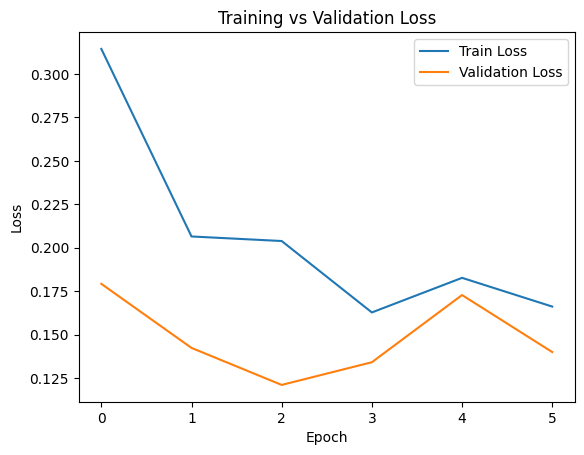

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=["Recyclable", "Non-Recyclable"]))

NameError: name 'model' is not defined

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Recyclable", "Non-Recyclable"],
            yticklabels=["Recyclable", "Non-Recyclable"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import random

split_base = "/content/drive/MyDrive/#3 - Data Science Project/SplitDataset"

train_dir = os.path.join(split_base, "train")
val_dir = os.path.join(split_base, "val")
test_dir = os.path.join(split_base, "test")

classes = ["Recyclable", "Non_Recyclable"]

for split in [train_dir, val_dir, test_dir]:
    for cls in classes:
        os.makedirs(os.path.join(split, cls), exist_ok=True)

def split_data(src_dir, train_dir, val_dir, test_dir):
    images = os.listdir(src_dir)
    random.shuffle(images)

    total = len(images)
    train_end = int(0.8 * total)
    val_end = int(0.9 * total)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for img in train_imgs:
        shutil.copy(os.path.join(src_dir, img), os.path.join(train_dir, img))
    for img in val_imgs:
        shutil.copy(os.path.join(src_dir, img), os.path.join(val_dir, img))
    for img in test_imgs:
        shutil.copy(os.path.join(src_dir, img), os.path.join(test_dir, img))

split_data(resized_recyclable,
           os.path.join(train_dir, "Recyclable"),
           os.path.join(val_dir, "Recyclable"),
           os.path.join(test_dir, "Recyclable"))

split_data(resized_non_recyclable,
           os.path.join(train_dir, "Non_Recyclable"),
           os.path.join(val_dir, "Non_Recyclable"),
           os.path.join(test_dir, "Non_Recyclable"))

print("Split complete!")

Split complete!


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(train_dir, transform=train_transform)
val_data   = datasets.ImageFolder(val_dir,   transform=val_test_transform)
test_data  = datasets.ImageFolder(test_dir,  transform=val_test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=32)
test_loader  = DataLoader(test_data,  batch_size=32)

In [ ]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32*56*56, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.net(x)

model = CNN()

In [ ]:
from torchvision import models

model = models.mobilenet_v2(pretrained=True)
model.classifier[1] = nn.Linear(model.last_channel, 2)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 98.0MB/s]


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

best_val_loss = float('inf')
patience = 3
counter = 0

for epoch in range(10):
    model.train()

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    print(f"Epoch {epoch}: Val Loss = {val_loss}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

Epoch 0: Val Loss = 11.191655809991062
Epoch 1: Val Loss = 13.486621976364404
Epoch 2: Val Loss = 9.131894209305756
Epoch 3: Val Loss = 7.498168945218822
Epoch 4: Val Loss = 7.660359961912036
Epoch 5: Val Loss = 4.170815730758477
Epoch 6: Val Loss = 3.6692801155149937
Epoch 7: Val Loss = 4.316594820818864
Epoch 8: Val Loss = 5.604238932952285
Epoch 9: Val Loss = 3.8951337914913893
Early stopping triggered


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.numpy())

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96       677
           1       0.96      0.98      0.97       885

    accuracy                           0.97      1562
   macro avg       0.97      0.96      0.97      1562
weighted avg       0.97      0.97      0.97      1562



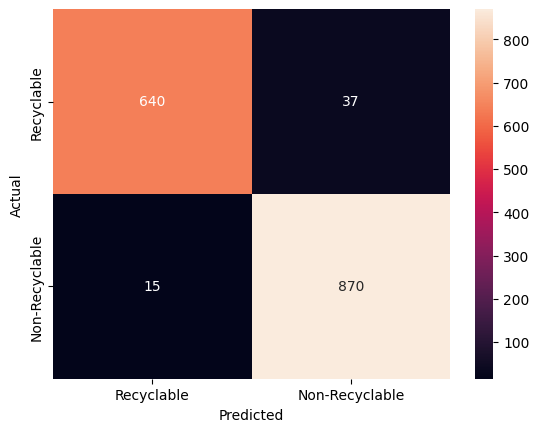

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Recyclable", "Non-Recyclable"],
            yticklabels=["Recyclable", "Non-Recyclable"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

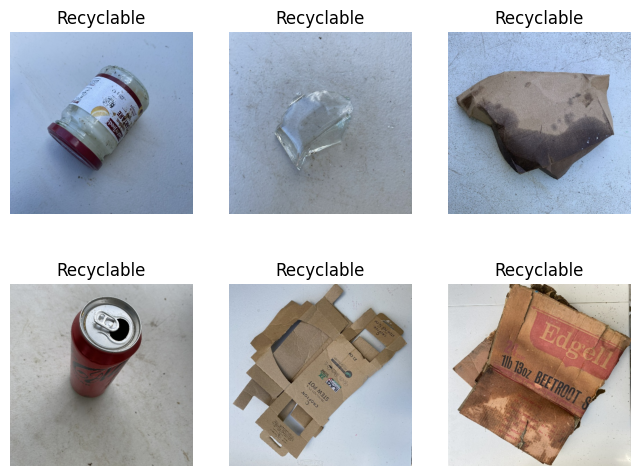

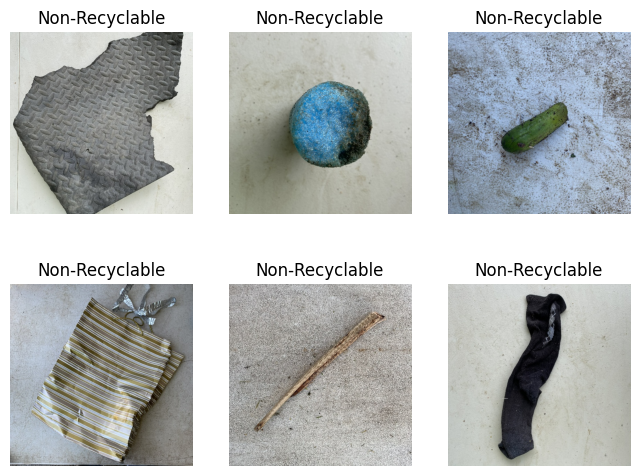

In [ ]:
import random
from PIL import Image

def show_samples(folder, title):
    images = random.sample(os.listdir(folder), 6)

    plt.figure(figsize=(8, 6))
    for i, img_name in enumerate(images):
        img = Image.open(os.path.join(folder, img_name))
        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(title)
        plt.axis("off")
    plt.show()

show_samples(recyclable_dir, "Recyclable")
show_samples(non_recyclable_dir, "Non-Recyclable")

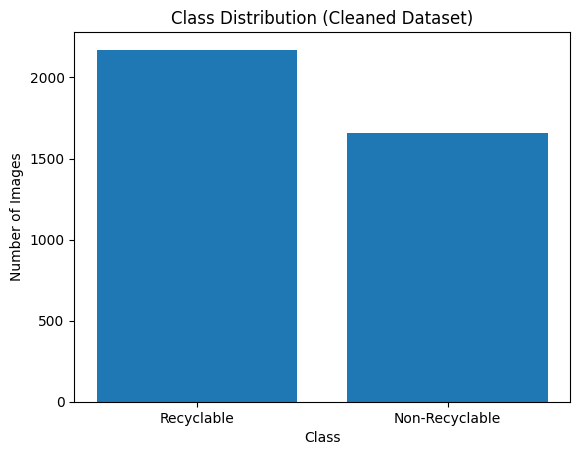

In [ ]:
import matplotlib.pyplot as plt

labels = ["Recyclable", "Non-Recyclable"]
counts = [
    len(os.listdir(recyclable_dir)),
    len(os.listdir(non_recyclable_dir))
]

plt.figure()
plt.bar(labels, counts)
plt.title("Class Distribution (Cleaned Dataset)")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

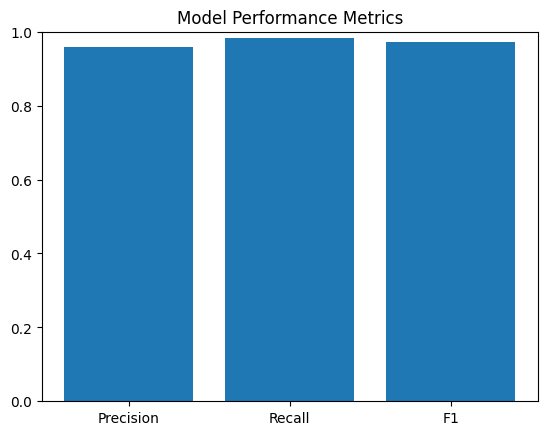

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

metrics = ["Precision", "Recall", "F1"]
values = [precision, recall, f1]

plt.figure()
plt.bar(metrics, values)
plt.title("Model Performance Metrics")
plt.ylim(0,1)
plt.show()